In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from src.shash_torch import Shash
import numpy as np
import torch

In [4]:
model_spec = 'cnn3d_gelu_0_5/level=slgt_small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'
#model_spec = 'cnn3d_3_layer/level=small_glade_new/opt=Adam_lr=0.001_batch=8_crit=ShashNLL'

In [5]:
results = xr.open_dataset(f'results/predictions/{model_spec}/predictions.nc')

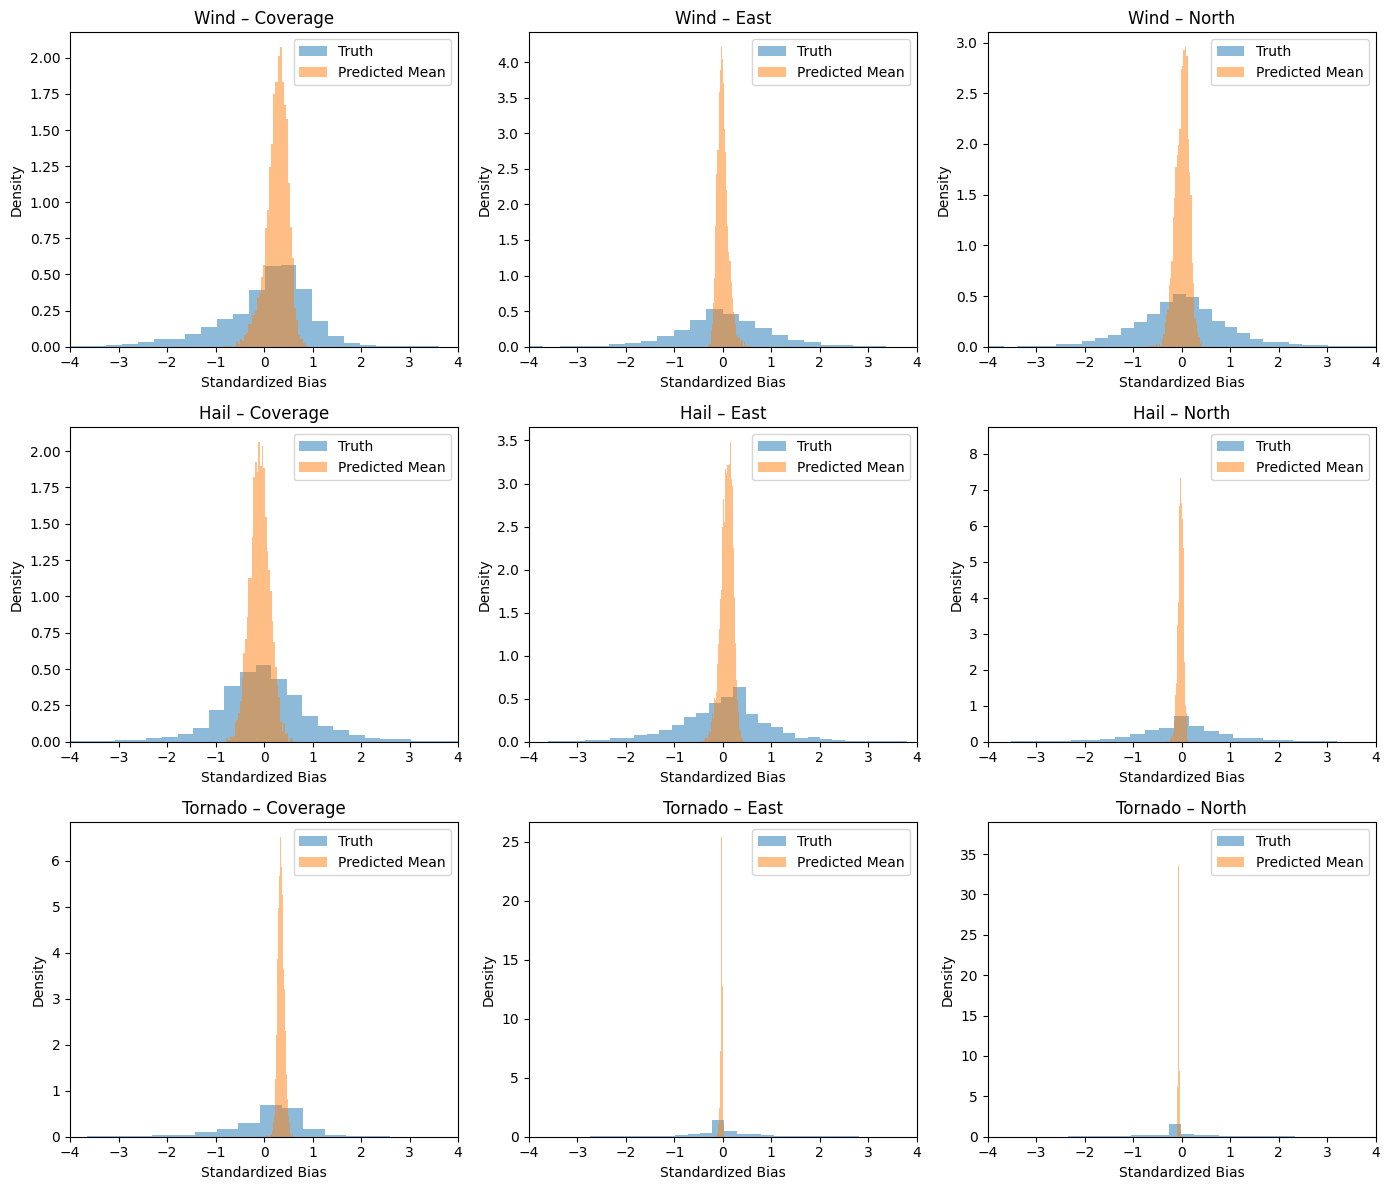

In [12]:
mu = results["mu"].values
truth = results["truth"].values

hazards = ["Wind", "Hail", "Tornado"]
variables = ["Coverage", "East", "North"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=False, sharey=False)

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):
        k = i * 3 + j  # flattened index
        
        ax = axes[i, j]
        
        ax.hist(truth[:, k], bins=40, density=True, alpha=0.5, label="Truth")
        ax.hist(mu[:, k], bins=40, density=True, alpha=0.5, label="Predicted Mean")
        ax.set_xlim(-4, 4)
        
        ax.set_title(f"{hazard} – {var}")
        ax.set_xlabel("Standardized Bias")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.show()

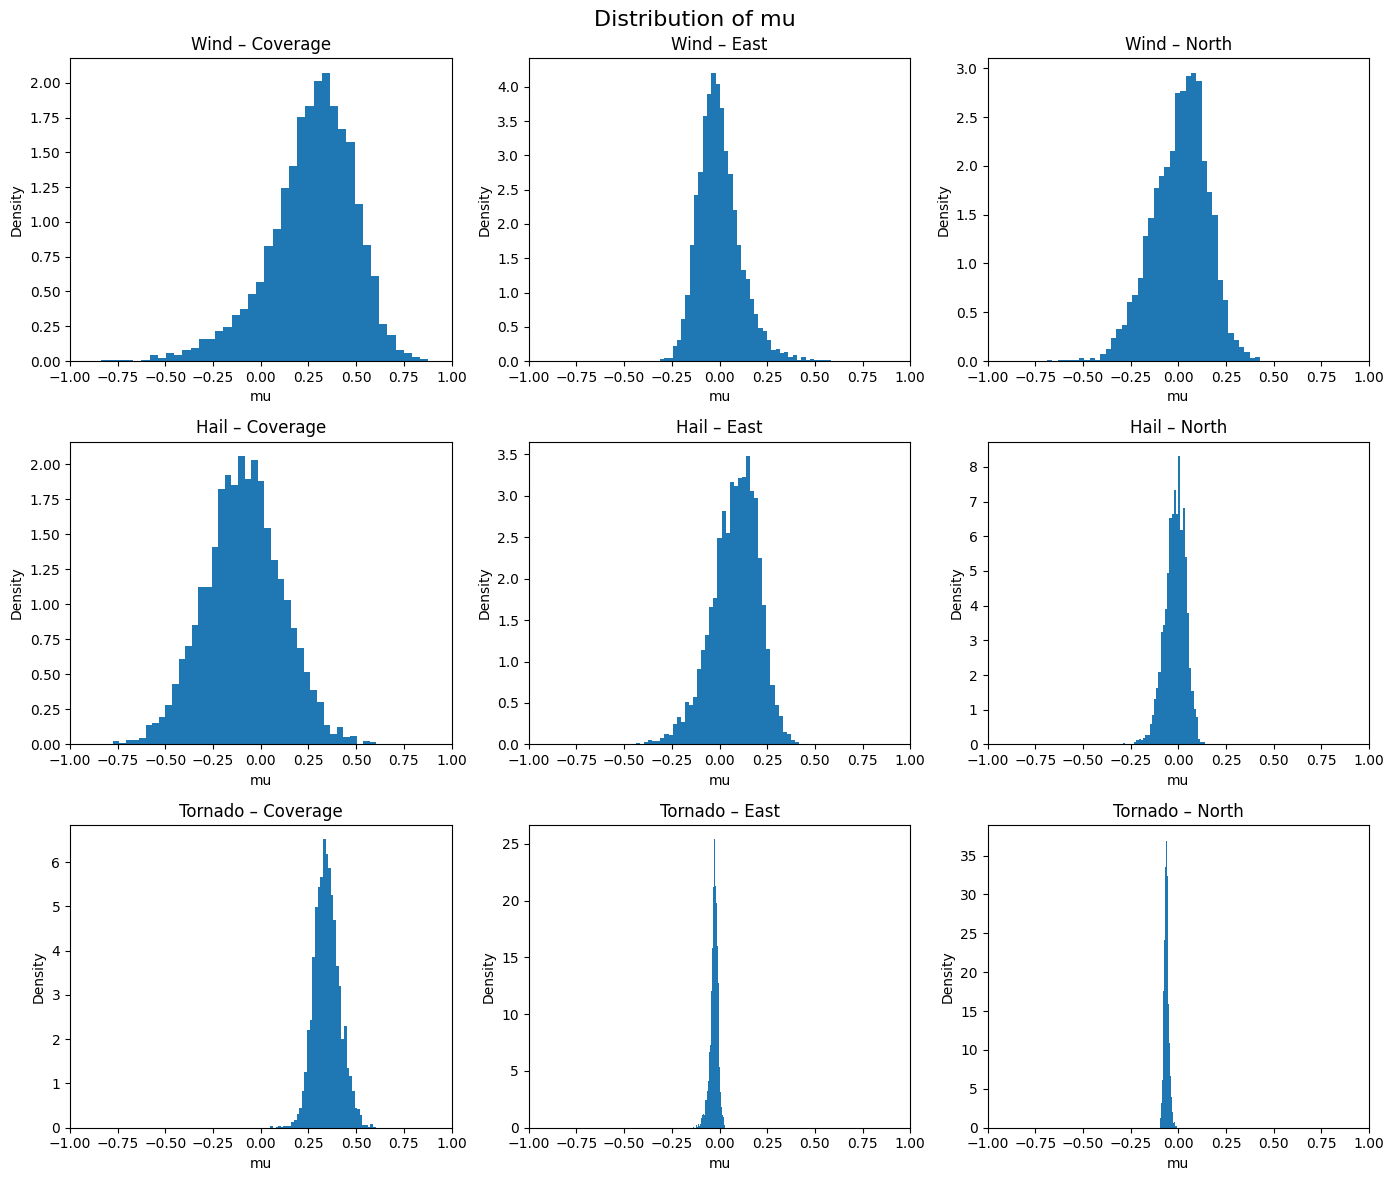

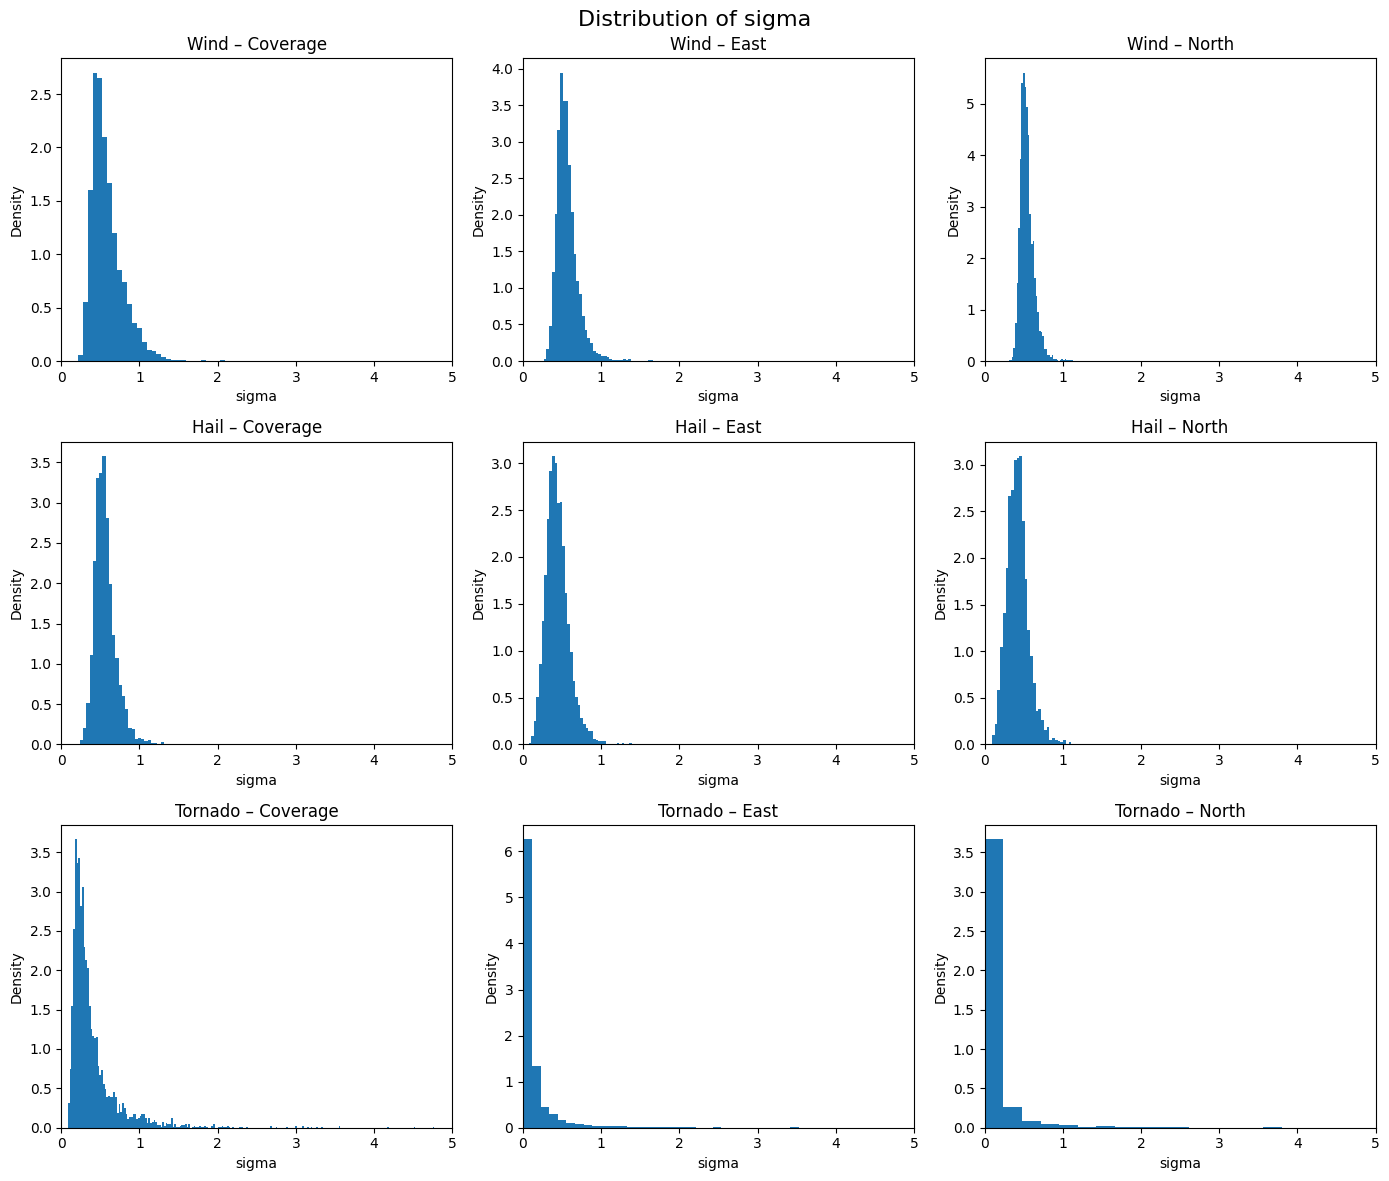

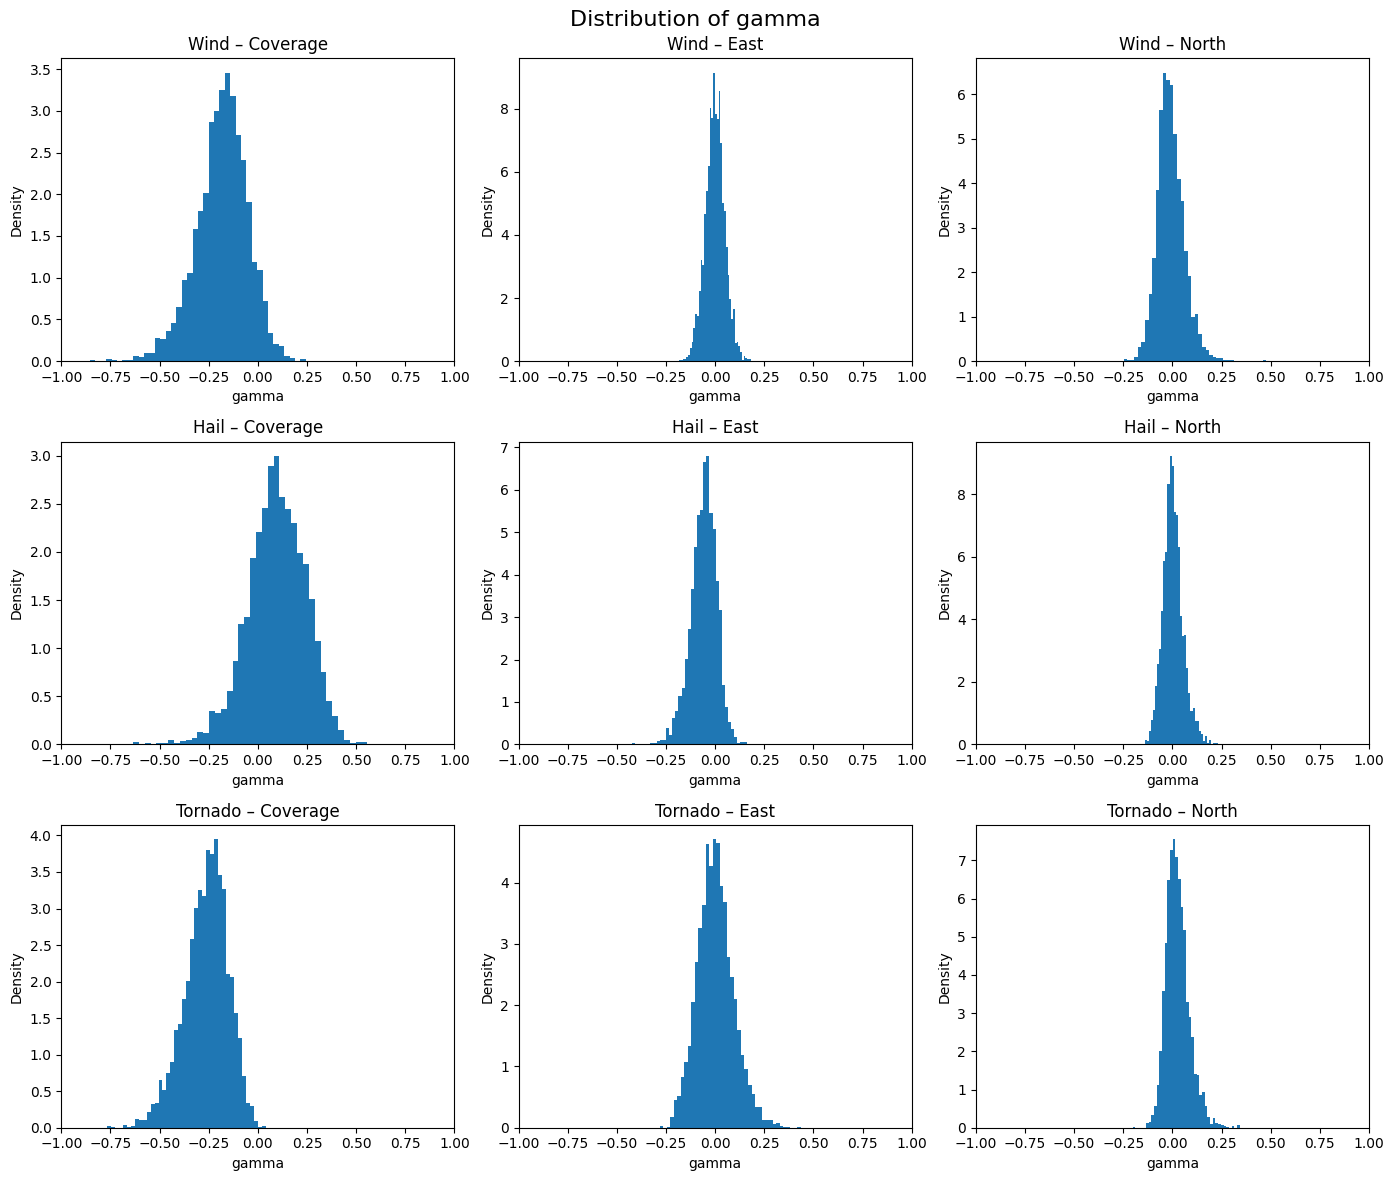

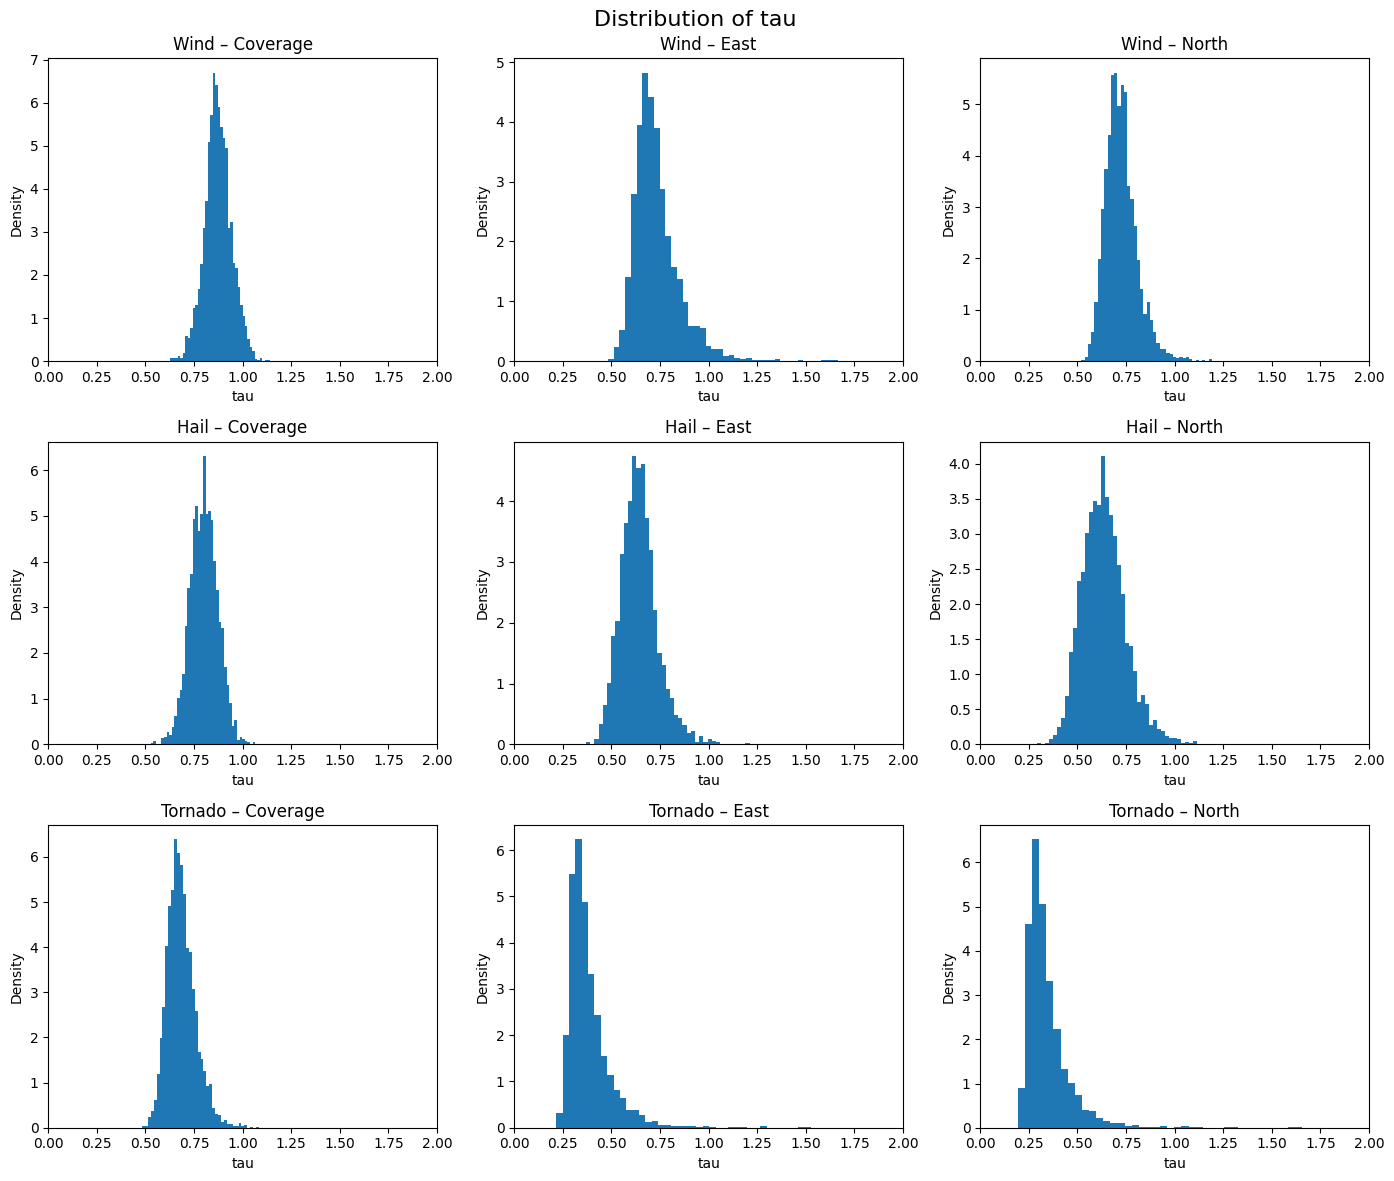

In [13]:
mu = results["mu"].values
sigma = results["sigma"].values
gamma = results["gamma"].values
tau = results["tau"].values

param_dict = {
    "mu": mu,
    "sigma": sigma,
    "gamma": gamma,
    "tau": tau
}

for param_name, values in param_dict.items():
    
    fig, axes = plt.subplots(3, 3, figsize=(14, 12), sharex=False, sharey=False)
    
    for i, hazard in enumerate(hazards):
        for j, var in enumerate(variables):
            k = i * 3 + j  # flattened index
            bins = 40
            ax = axes[i, j]
            if param_name == 'mu':
                ax.set_xlim(-1, 1)
            elif param_name == 'sigma':
                ax.set_xlim(0, 5)
                if hazard == 'Tornado':
                    bins = 400
            elif param_name == 'gamma':
                ax.set_xlim(-1, 1)
            elif param_name == 'tau':
                ax.set_xlim(0, 2)


            
            ax.hist(values[:, k], bins=bins, density=True)
            
            ax.set_title(f"{hazard} – {var}")
            ax.set_xlabel(param_name)
            ax.set_ylabel("Density")
    
    fig.suptitle(f"Distribution of {param_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

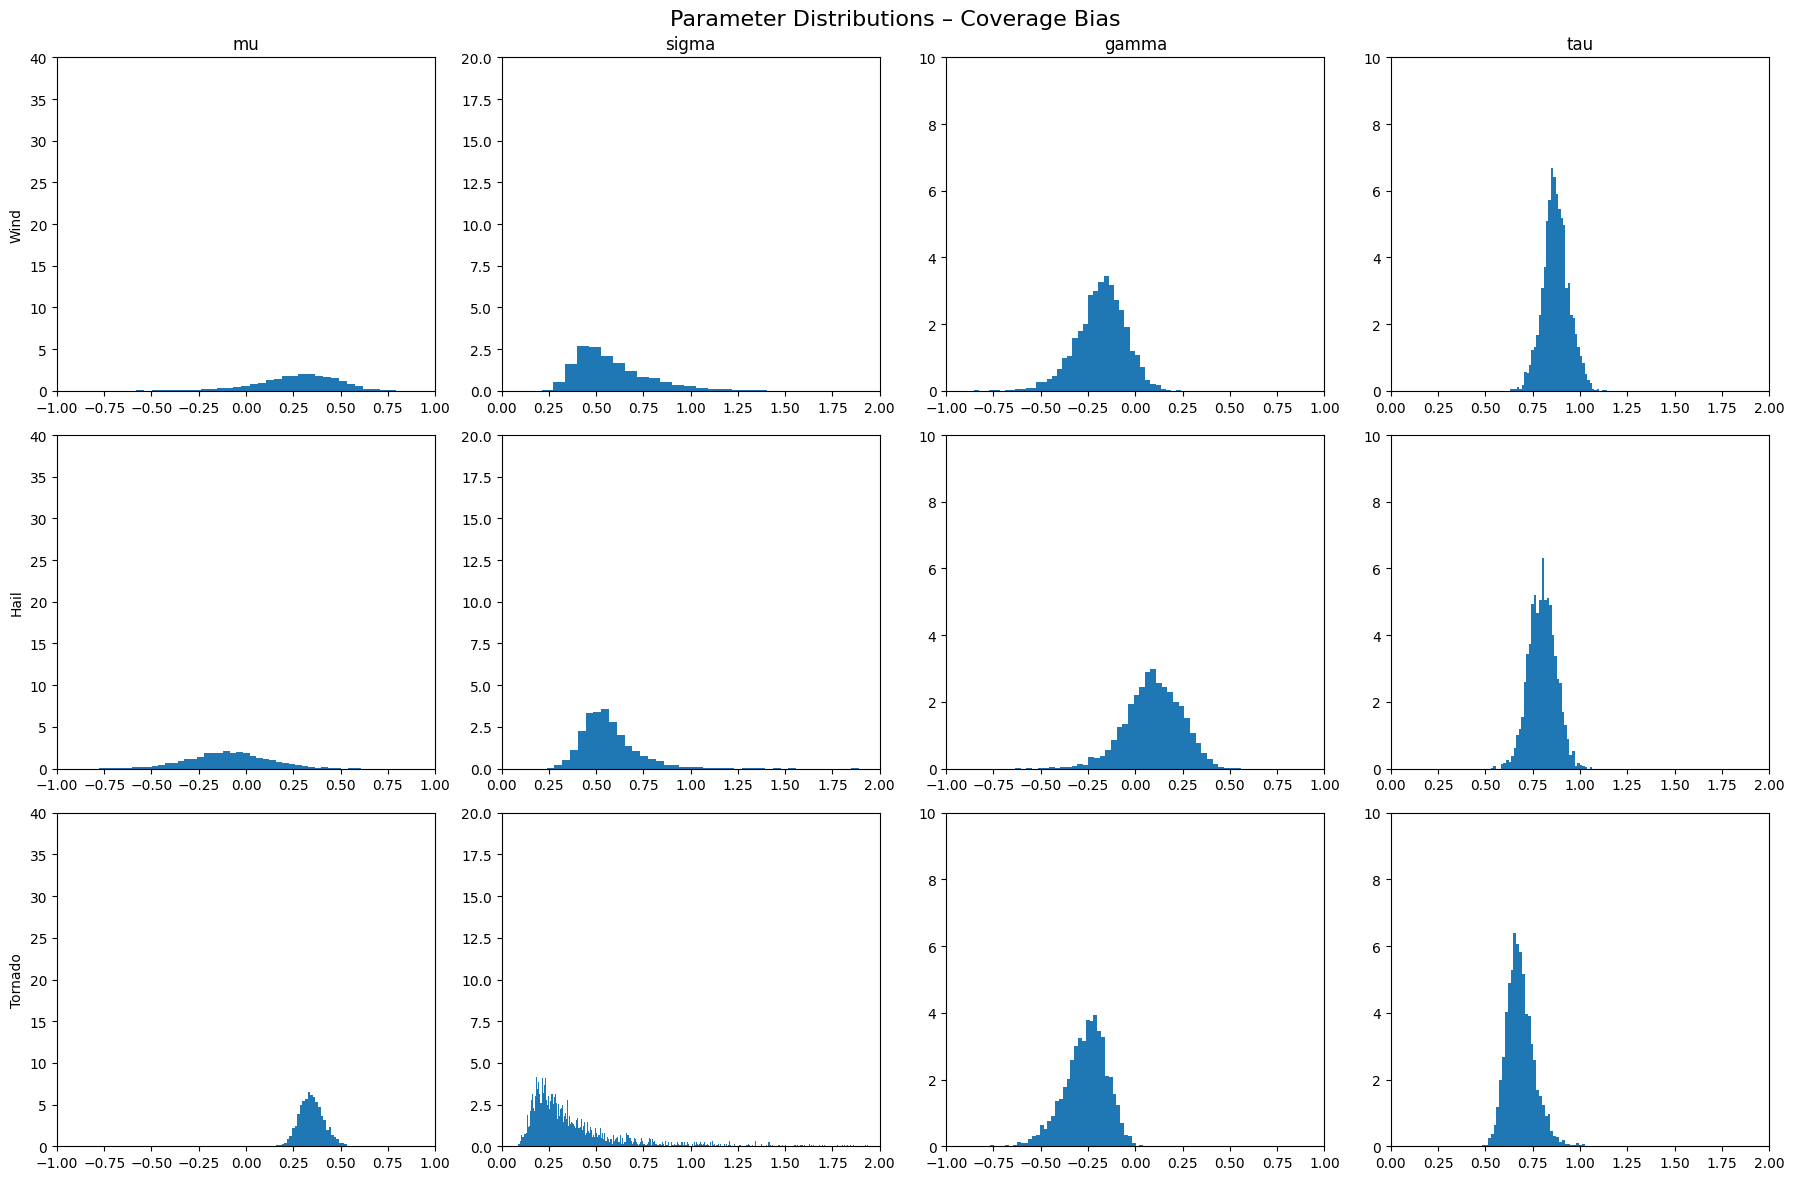

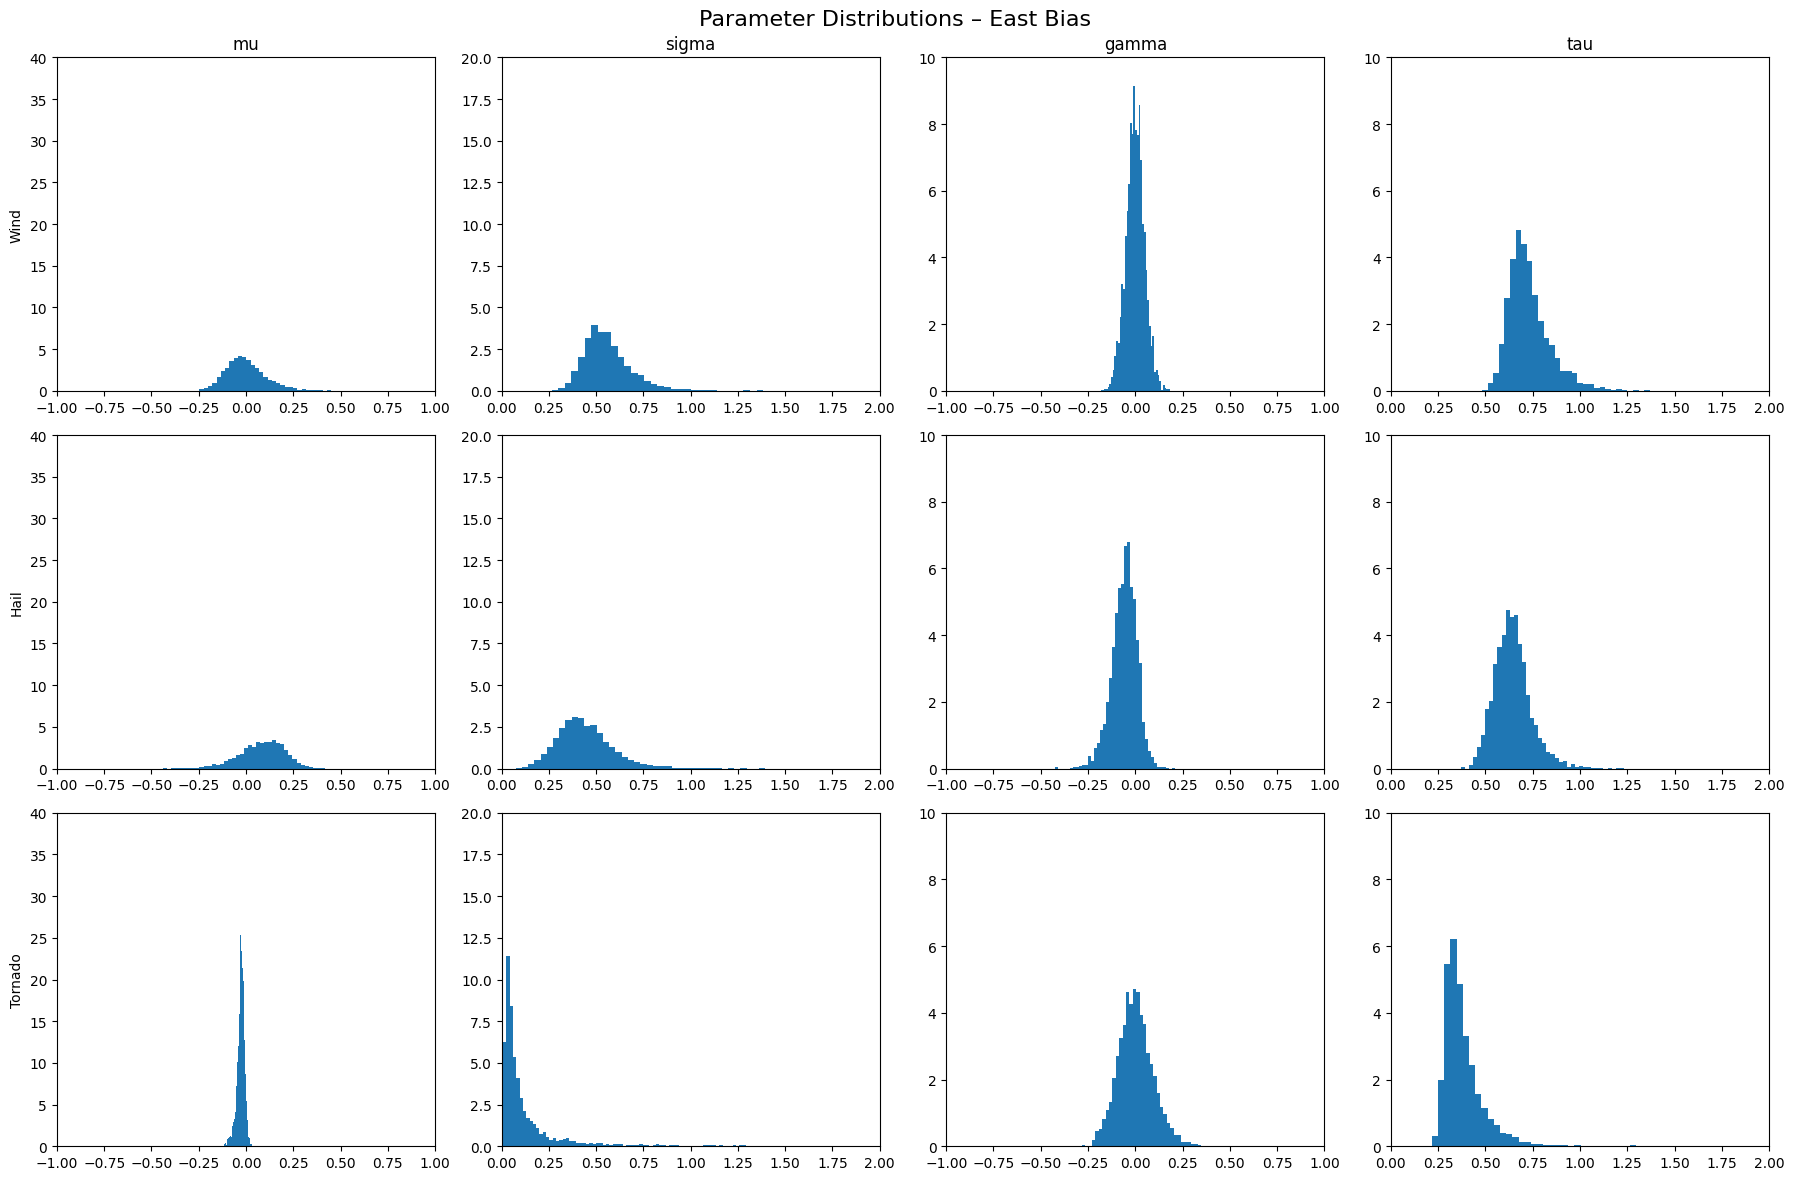

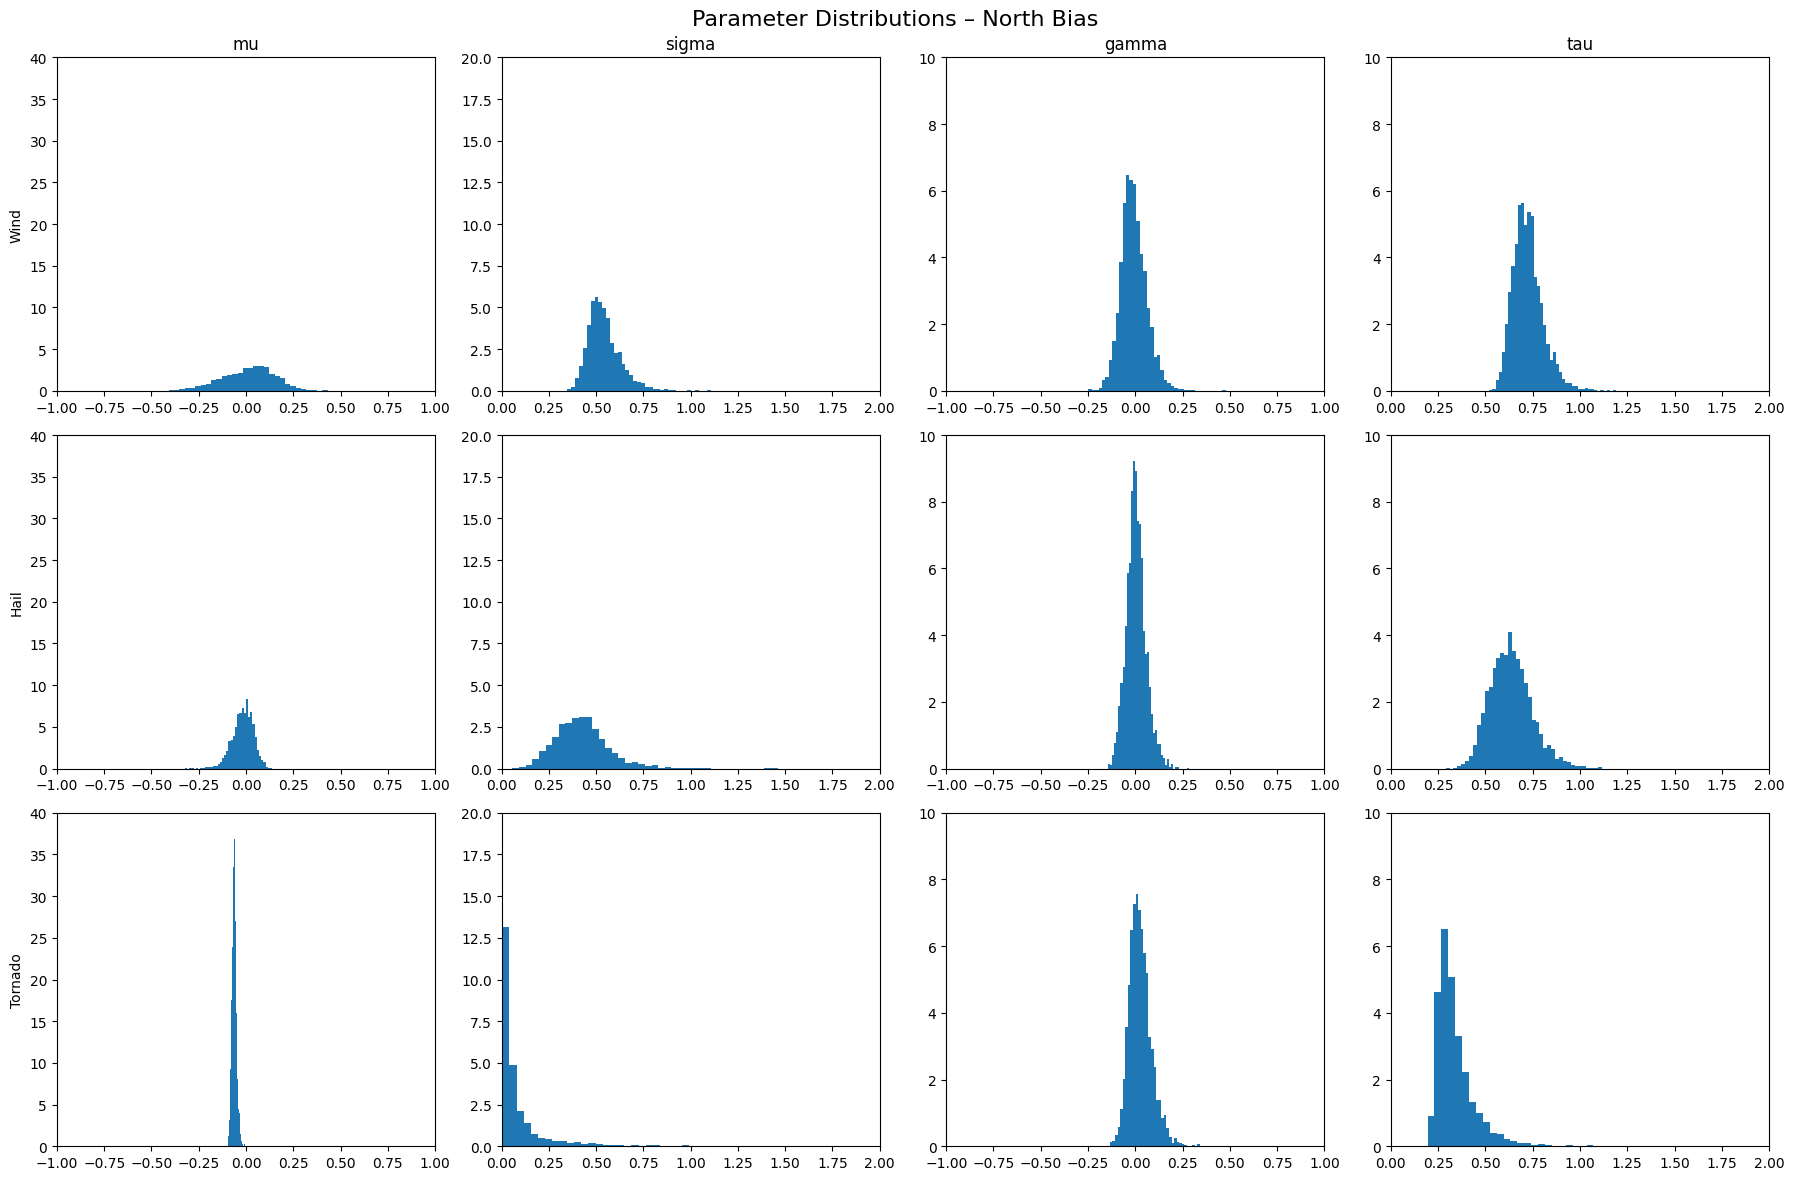

In [14]:
params = ["mu", "sigma", "gamma", "tau"]
mu = results["mu"].values
sigma = results["sigma"].values
gamma = results["gamma"].values
tau = results["tau"].values

param_dict = {
    "mu": mu,
    "sigma": sigma,
    "gamma": gamma,
    "tau": tau
}

for j, var in enumerate(variables):

    fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=False, sharey=False)

    for i, hazard in enumerate(hazards):
        for p, param_name in enumerate(params):

            k = i * 3 + j  # flattened index
            
            ax = axes[i, p]
            values = param_dict[param_name]

            bins = 40

            # Parameter-specific limits
            if param_name == "mu":
                ax.set_xlim(-1, 1)
                ax.set_ylim(0, 40)
            elif param_name == "sigma":
                ax.set_xlim(0, 2)
                ax.set_ylim(0, 20)
                if hazard == "Tornado":
                    bins = 2500
            elif param_name == "gamma":
                ax.set_xlim(-1, 1)
                ax.set_ylim(0, 10)
            elif param_name == "tau":
                ax.set_xlim(0, 2)
                ax.set_ylim(0, 10)

            ax.hist(values[:, k], bins=bins, density=True)

            if i == 0:
                ax.set_title(param_name)

            if p == 0:
                ax.set_ylabel(hazard)

            #ax.set_xlabel(param_name)

    fig.suptitle(f"Parameter Distributions – {var} Bias", fontsize=16)
    plt.tight_layout()
    plt.show()

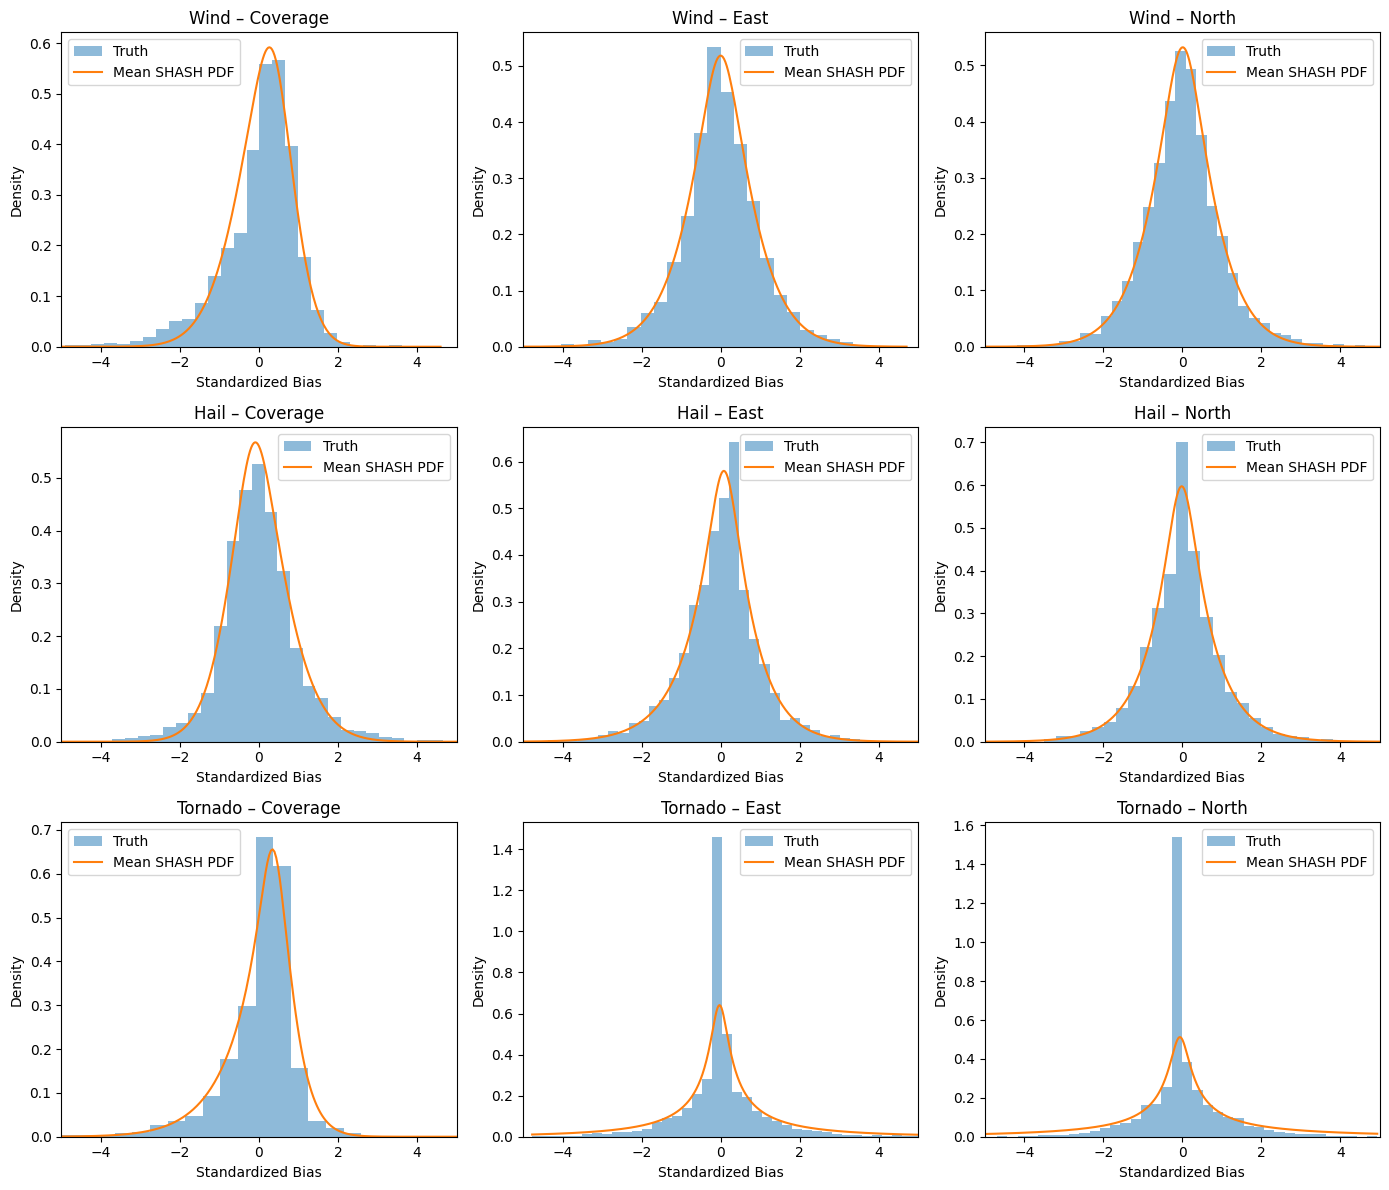

In [15]:
# Extract arrays
mu = results["mu"].values
sigma = results["sigma"].values
gamma = results["gamma"].values
tau = results["tau"].values
truth = results["truth"].values

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):
        k = i * 3 + j
        
        ax = axes[i, j]
        ax.set_xlim(-5, 5)
        
        # Histogram of truth
        ax.hist(truth[:, k], bins=40, density=True, alpha=0.5, label="Truth")
        
        # Compute mean parameters
        mu_bar = mu[:, k].mean()
        sigma_bar = sigma[:, k].mean()
        gamma_bar = gamma[:, k].mean()
        tau_bar = tau[:, k].mean()
        
        # Build Shash distribution with mean parameters
        params = torch.tensor([[mu_bar, sigma_bar, gamma_bar, tau_bar]])
        dist = Shash(params)
        
        # Create evaluation grid
        x_min = truth[:, k].min()
        x_max = truth[:, k].max()
        x = np.linspace(x_min, x_max, 400)
        
        pdf = dist.prob(torch.tensor(x)).detach().numpy().flatten()
        
        # Overlay PDF
        ax.plot(x, pdf, label="Mean SHASH PDF")
        
        ax.set_title(f"{hazard} – {var}")
        ax.set_xlabel("Standardized Bias")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.show()

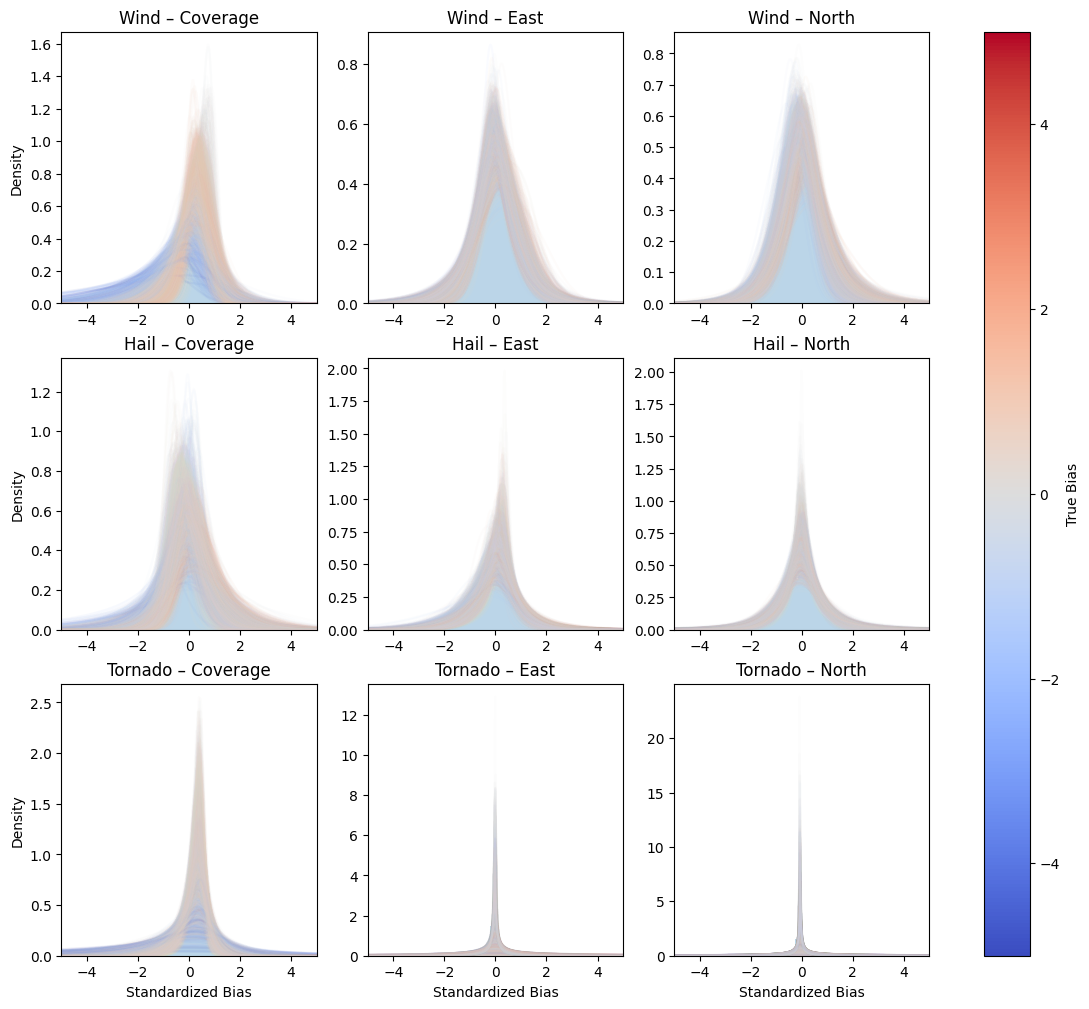

In [18]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# Extract arrays
mu = results["mu"].values
sigma = results["sigma"].values
gamma = results["gamma"].values
tau = results["tau"].values
truth = results["truth"].values

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

cmap = cm.get_cmap("coolwarm")
norm = mcolors.Normalize(vmin=-5, vmax=5)

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):
        k = i * 3 + j
        ax = axes[i, j]
        ax.set_xlim(-5, 5)

        ax.hist(truth[:, k], bins=40, density=True, alpha=0.3)

        x = np.linspace(-5, 5, 400)
        x_tensor = torch.tensor(x)

        for n in range(mu.shape[0]):
            params = torch.tensor([[mu[n, k],
                                    sigma[n, k],
                                    gamma[n, k],
                                    tau[n, k]]])
            dist = Shash(params)
            pdf = dist.prob(x_tensor).detach().numpy().flatten()

            color = cmap(norm(truth[n, k]))
            ax.plot(x, pdf, color=color, alpha=.05)

        ax.set_title(f"{hazard} – {var}")
        if hazard == 'Tornado':
            ax.set_xlabel("Standardized Bias")
        if var == 'Coverage':
            ax.set_ylabel("Density")
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation="vertical", label="True Bias")
plt.savefig('figs/distributions/all_pdfs.pdf')
plt.show()


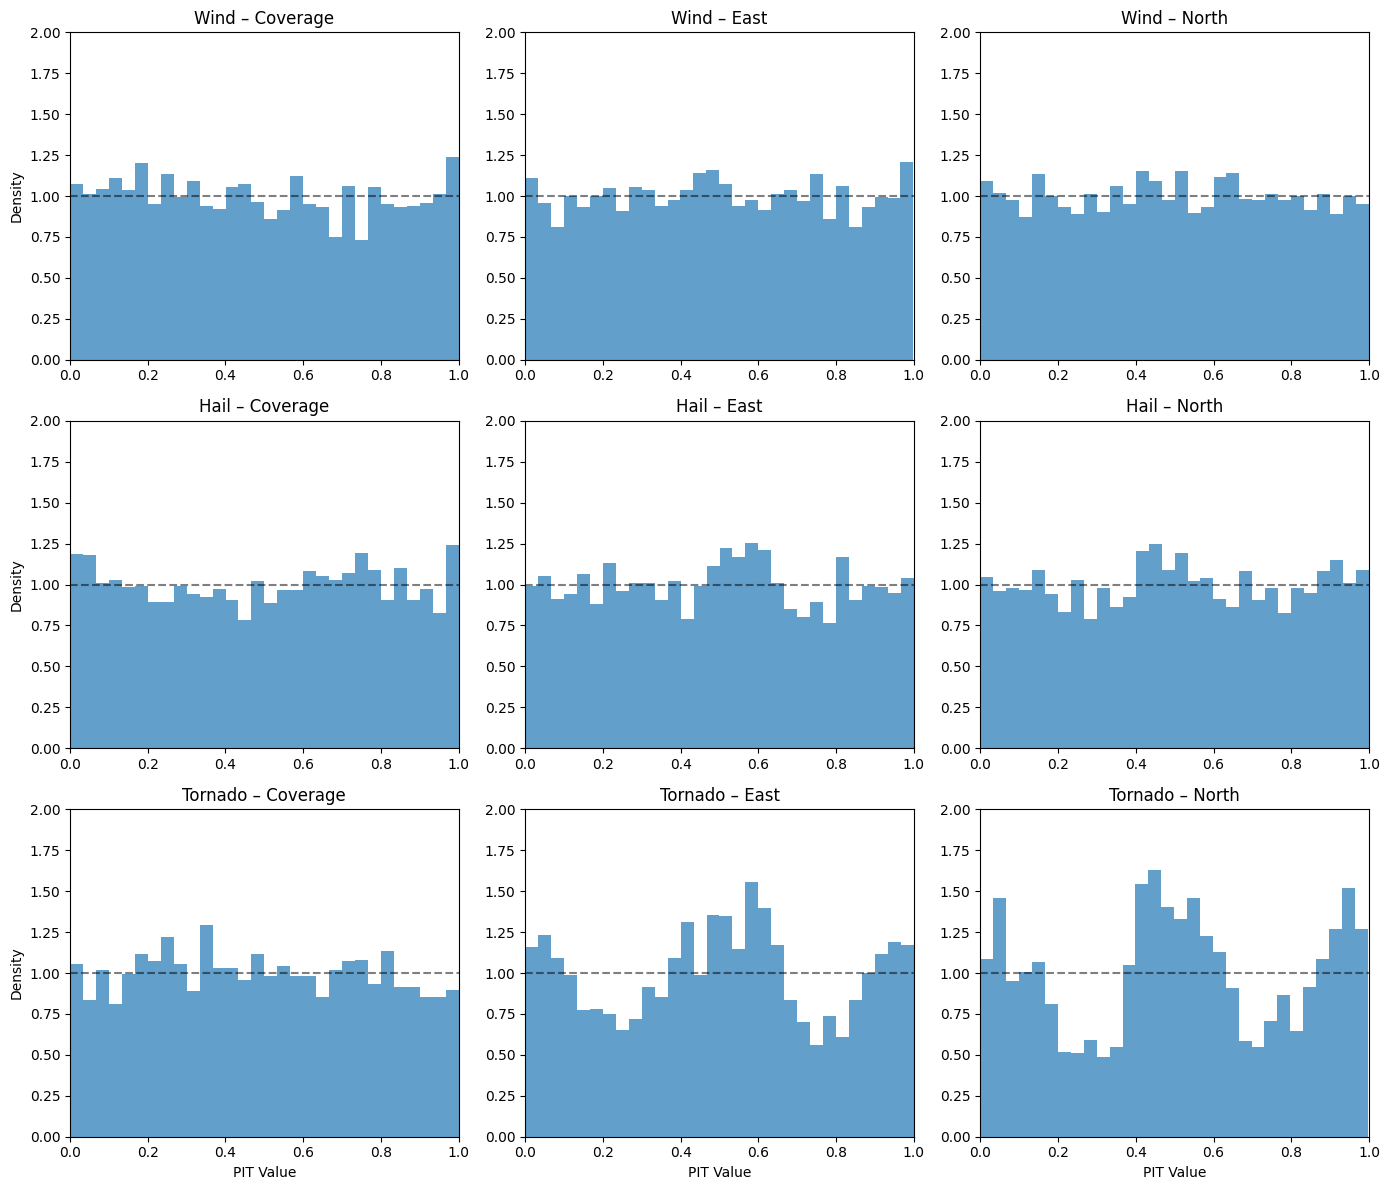

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, hazard in enumerate(hazards):
    for j, var in enumerate(variables):

        k = i * 3 + j
        ax = axes[k]

        # Build parameter tensor for SHASH distribution
        params = np.stack([
            mu[:, k],
            sigma[:, k],
            gamma[:, k],
            tau[:, k]
        ], axis=-1)

        shash = Shash(torch.tensor(params))

        # PIT values
        pit_vals = shash.cdf(torch.tensor(truth[:, k])).detach().numpy()

        # Histogram of PIT values
        ax.hist(pit_vals, bins=30, density=True, alpha=0.7)

        ax.plot([0, 1], [1, 1], "k--", alpha=0.5)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 2)
        

        ax.set_title(f"{hazard} – {var}")
        if hazard == 'Tornado':
            ax.set_xlabel("PIT Value")
        if var == 'Coverage':
            ax.set_ylabel("Density")

plt.tight_layout()
plt.savefig('figs/distributions/calibration.pdf')
plt.show()